In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
out_dir = '.'
devices = ['cpu', 'gpu_b200']

In [3]:
def collect(runs_by_dim, dims, key):
    """Return (valid_dims, medians, all_values) skipping dims with no data."""
    valid_dims, medians, all_values = [], [], []
    for d in dims:
        if d not in runs_by_dim:
            continue
        vals = [row[key] for row in runs_by_dim[d]]
        valid_dims.append(d)
        medians.append(np.median(vals))
        all_values.append(vals)
    return np.array(valid_dims), medians, all_values

def any_row_has_key(runs_by_method, key):
    return any(
        key in row
        for runs_by_dim in runs_by_method.values()
        for rows in runs_by_dim.values()
        for row in rows
    )

def plot_series(ax, d_arr, medians, all_values, marker, label, color, linestyle='-'):
    if len(d_arr) == 0:
        return
    line, = ax.plot(d_arr, medians, marker=marker, linestyle=linestyle, label=label, color=color)
    for d, vals in zip(d_arr, all_values):
        ax.scatter([d] * len(vals), vals, marker=marker, color=color, alpha=0.25, s=15, zorder=3)

def style_axis(ax, dims, title, ylabel, fontsize):
    ax.set_xlabel('Dimension $d$', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks(dims)
    ax.set_xticklabels(dims, rotation=45, ha='right')
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

def plot_nonbasic(data, suptitle="", fontsize=12):

    dims = np.array(sorted(data['expm_scan'].keys()))

    runs_by_method = {
        'expm_scan':      data['expm_scan']     ,
        'expm_scan_jit':  data['expm_scan_jit'] ,
        'expm_assoc':     data['expm_assoc']    ,
        'expm_assoc_jit': data['expm_assoc_jit'],
    }
    methods = [
        ('expm_scan'      ,  's', '-' , 'orange', 'Scan (without JIT)'),
        ('expm_scan_jit'  ,  's', '--', 'orange', 'Scan (with JIT)'),
        ('expm_assoc'     ,  '^', '-' , 'green' , 'Associative Scan (without JIT)'),
        ('expm_assoc_jit' ,  '^', '--', 'green' , 'Associative Scan (with JIT)'),
    ]

    has_gpu_mem = any_row_has_key(runs_by_method, 'mem_gpu')

    fig1, axs1 = plt.subplots(2, 2, figsize=(6*2, 2*(3/4)*6), constrained_layout=True)
    fig2, axs2 = plt.subplots(1, 1, figsize=(1.5*5, 5), constrained_layout=True)
    axs = np.concatenate([axs1.flatten(), [axs2]])

    panels = [
        (axs[0], 't_batch',   methods, 'Time Batch (s)',   'Batch time vs. dimension',   'log'),
        (axs[1], 't_compose', methods, 'Time Compose (s)', 'Compose time vs. dimension', 'log'),
        (axs[2], 'mem_total', methods, 'Memory Host (MB)', 'Memory Host vs. dimension',  'log'),
    ]
    if has_gpu_mem:
        panels.append((axs[3], 'mem_gpu', methods, 'Memory GPU (MB)', 'Memory GPU vs. dimension', 'log'))
    else:
        panels.append((axs[3], None, None, None, None, None))

    panels.append((axs[4], 'perr', methods[2:], 'Max component difference', 'Propagator error vs. dimension', 'log'))

    for ax, key, ms, ylabel, title, yscale in panels:
        if key is None:
            continue
        for mkey, marker, linestyle, color, label in ms:
            plot_series(ax, *collect(runs_by_method[mkey], dims, key),
                        marker=marker, color=color, label=label, linestyle=linestyle)
        style_axis(ax, dims, title, ylabel, fontsize)
        ax.set_yscale(yscale)

    # All subplots share the same method legend; show it once to the right of the figure.
    handles, labels = [], []
    for ax in axs:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    fig1.legend(handles, labels, loc='outside right center', fontsize=fontsize)
    fig2.legend(handles, labels, loc='outside right center', fontsize=fontsize)

    if suptitle:
        fig1.suptitle(suptitle, fontsize=1.5*fontsize)
        fig2.suptitle(suptitle, fontsize=1.5*fontsize)
    
    plt.show()

# Plot all the other data

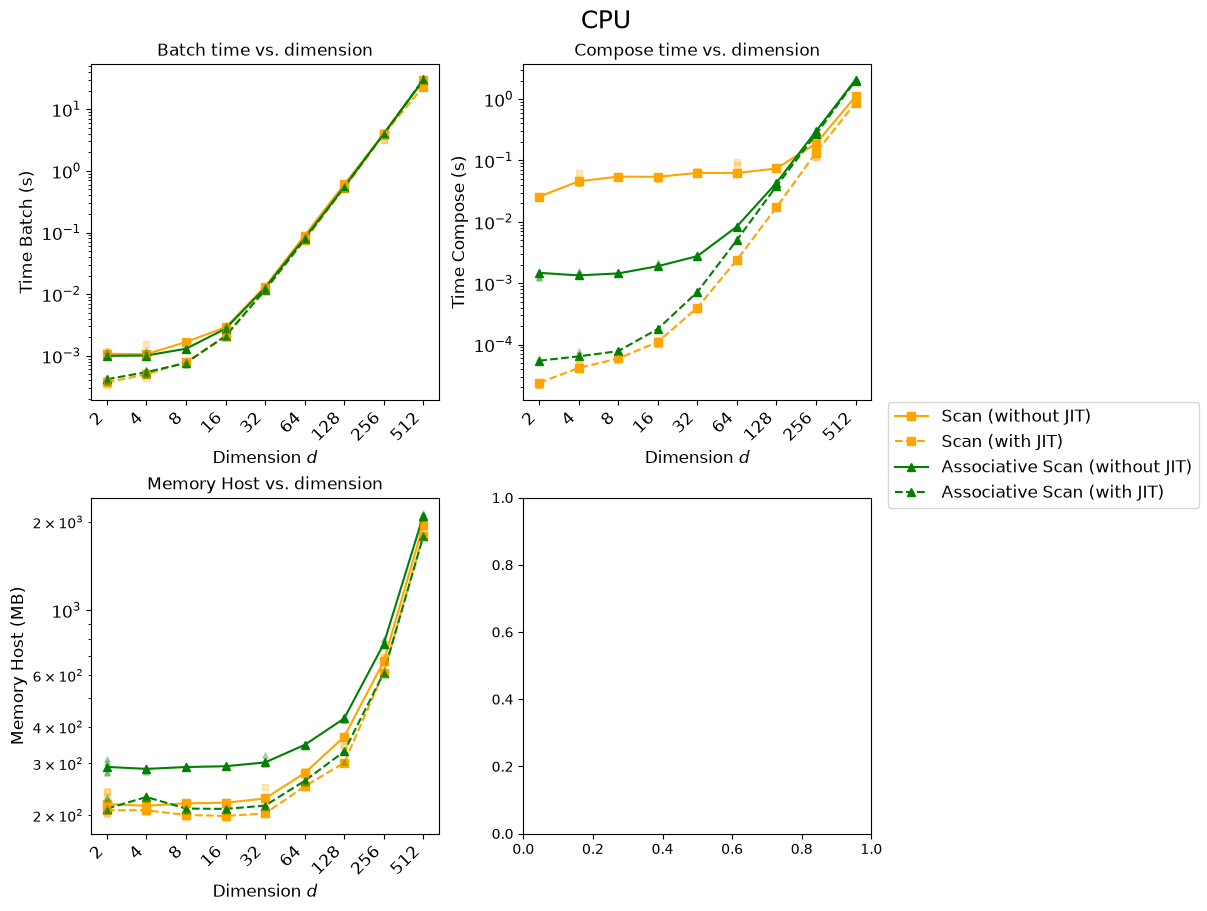

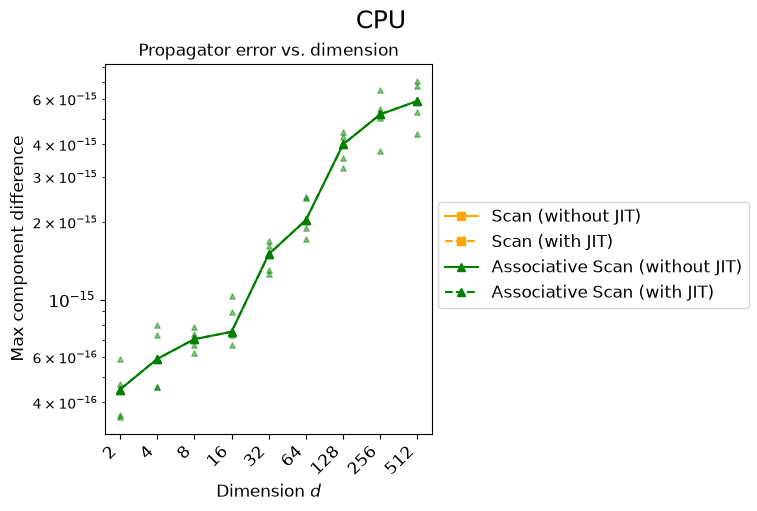

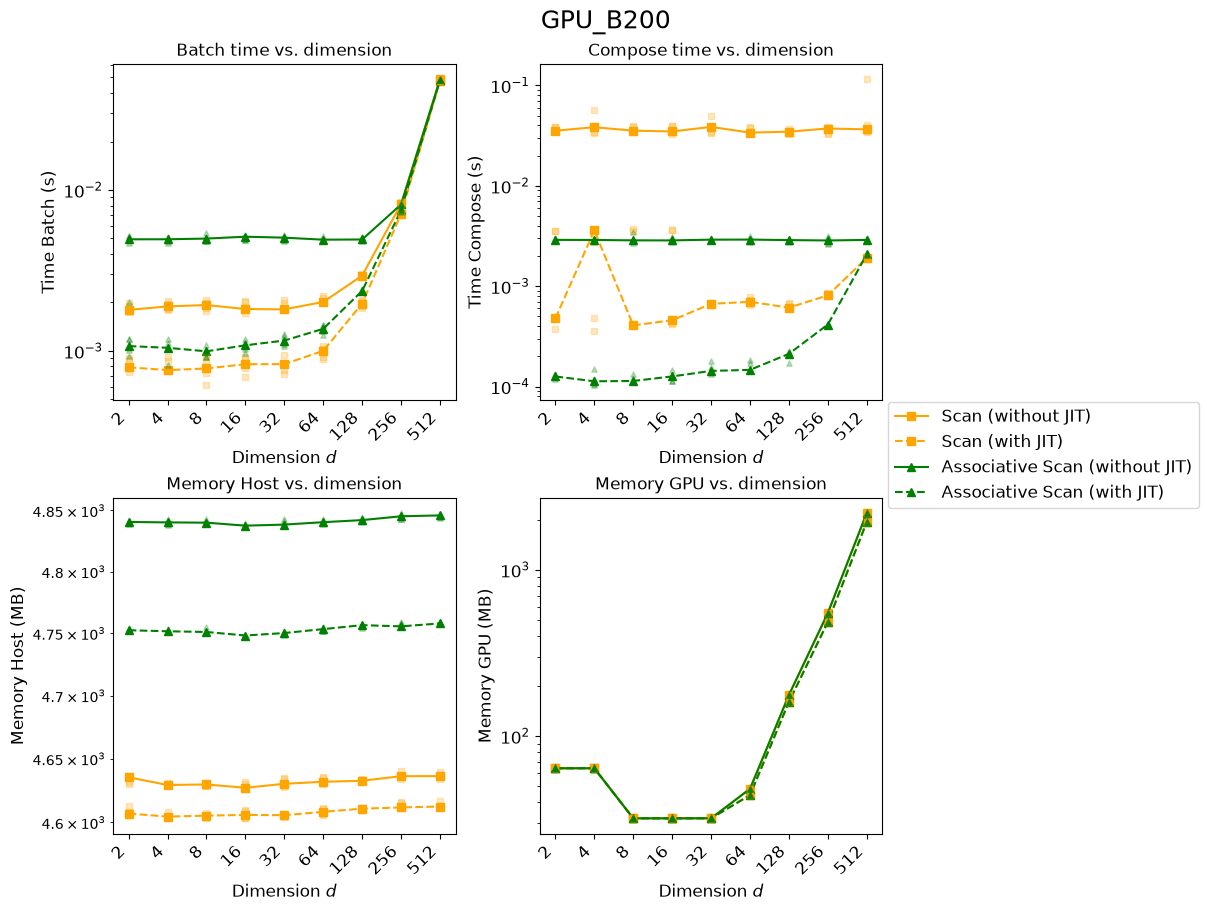

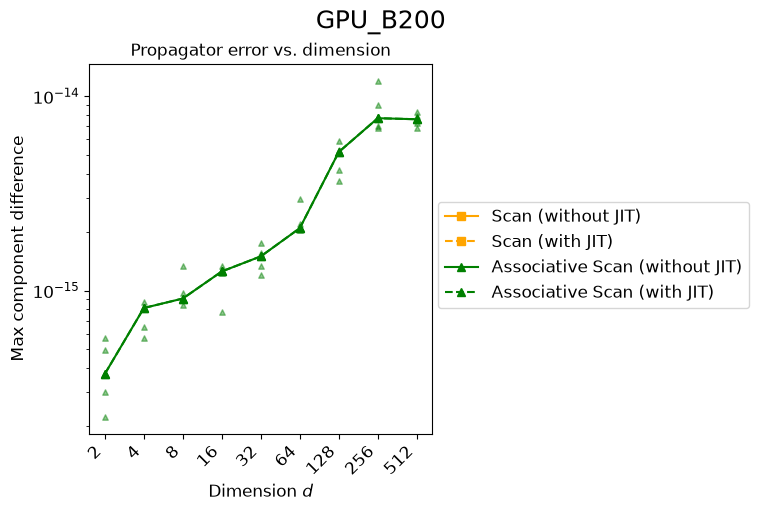

In [4]:
for device in devices:
    data = np.load(f'{out_dir}/{device}.npy', allow_pickle=True).item()
    plot_nonbasic(data, suptitle=f'{device.upper()}')